In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import pickle

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Find and load all spike_burst_rates_PF.pkl files
pattern = os.path.join(data_folder, 'CKII**', 'spike_burst_rates_PF.pkl')
pkl_files = glob.glob(pattern, recursive=True)
print(f'Found {len(pkl_files)} spike_burst_rates_PF files:')
for f in pkl_files:
    print(f'  {f}')

# Pool data
conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
rate_metrics_pooled = {
    'simple_rate': {cond: [] for cond in conditions},
    'burst_rate': {cond: [] for cond in conditions},
    'burst_prob': {cond: [] for cond in conditions},
}
burst_counts_pooled = {cond: [] for cond in conditions}
min_cb_bursts_per_condition = 10  # default

for pkl_path in pkl_files:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    rate_metrics = data['rate_metrics']
    burst_counts = data['burst_counts']
    min_cb_bursts_per_condition = data.get('min_cb_bursts_per_condition', 5)
    
    dataset_name = os.path.basename(os.path.dirname(pkl_path))
    n_cells = len(rate_metrics['simple_rate']['run_in'])
    
    for metric_key in ['simple_rate', 'burst_rate', 'burst_prob']:
        for cond in conditions:
            rate_metrics_pooled[metric_key][cond].extend(rate_metrics[metric_key][cond])
    
    for cond in conditions:
        burst_counts_pooled[cond].extend(burst_counts[cond])
    
    print(f'Loaded {dataset_name}: {n_cells} cells')

# Print summary
print(f'\nTotal pooled cells:')
for cond in conditions:
    n = len(rate_metrics_pooled['simple_rate'][cond])
    print(f'  {cond}: {n} cells')

Found 4 spike_burst_rates_PF files:
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce21_PR_20250806/spike_burst_rates_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce45_PX_20260118/spike_burst_rates_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce47_PX_20260128/spike_burst_rates_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/spike_burst_rates_PF.pkl
Loaded CKII_pAce21_PR_20250806: 4 cells
Loaded CKII_pAce45_PX_20260118: 6 cells
Loaded CKII_pAce47_PX_20260128: 4 cells
Loaded CKII_pAce38_PX_20251126: 7 cells

Total pooled cells:
  run_in: 21 cells
  run_out: 21 cells
  rest_in: 21 cells
  rest_out: 21 cells


In [4]:
# Plotting functions

def _paired_test(vals_in, vals_out):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def _global_ylim_from_vals(vals, pad_frac=0.08):
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        return None
    y_min = np.nanmin(finite)
    y_max = np.nanmax(finite)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

Locomotion SS rate (Hz) (wilcoxon): n=21, stat=0, p=9.54e-07, shapiro_p=7.64e-06
Locomotion CB rate (Hz) (paired t-test): n=17, stat=6.23, p=1.21e-05, shapiro_p=0.341
Locomotion CB prob. (wilcoxon): n=17, stat=0, p=1.53e-05, shapiro_p=0.000117
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/SpikeBurstRates_run_pooled.svg


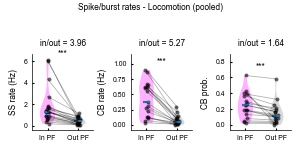

Quiet SS rate (Hz) (wilcoxon): n=21, stat=1, p=1.91e-06, shapiro_p=0.000114
Quiet CB rate (Hz) (paired t-test): n=20, stat=4.21, p=0.000471, shapiro_p=0.586
Quiet CB prob. (wilcoxon): n=20, stat=103, p=0.956, shapiro_p=0.022
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/SpikeBurstRates_rest_pooled.svg


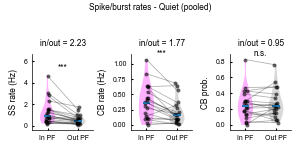

In [5]:
# Plot pooled spike/burst rates

rate_metrics = rate_metrics_pooled
burst_counts = burst_counts_pooled

state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

metric_specs = [
    ('simple_rate', 'SS rate (Hz)'),
    ('burst_rate', 'CB rate (Hz)'),
    ('burst_prob', 'CB prob.'),
]

panel_w = 1.0
panel_h = 1.5
xlim = (0.5, 2.5)

# Compute global y limits for each metric
metric_ylim = {}
for metric_key, _ in metric_specs:
    all_vals = []
    for cond in conditions:
        arr = np.asarray(rate_metrics[metric_key][cond], dtype=float)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            all_vals.append(finite)
    if all_vals:
        metric_ylim[metric_key] = _global_ylim_from_vals(np.concatenate(all_vals))
    else:
        metric_ylim[metric_key] = None

for state_key, state_label in state_specs:
    fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]
    cond_labels = ['In PF', 'Out PF']

    counts_in = np.asarray(burst_counts[conds[0]], dtype=float)
    counts_out = np.asarray(burst_counts[conds[1]], dtype=float)
    if counts_in.size > 0 and counts_out.size > 0:
        pair_mask_cb = ~((counts_in < min_cb_bursts_per_condition) & (counts_out < min_cb_bursts_per_condition))
    else:
        pair_mask_cb = np.array([], dtype=bool)

    for ax, (metric_key, ylabel) in zip(axes, metric_specs):
        vals_in_raw = np.asarray(rate_metrics[metric_key][conds[0]], dtype=float)
        vals_out_raw = np.asarray(rate_metrics[metric_key][conds[1]], dtype=float)
        if metric_key in ('burst_rate', 'burst_prob') and pair_mask_cb.size > 0:
            vals_in = vals_in_raw[pair_mask_cb]
            vals_out = vals_out_raw[pair_mask_cb]
        else:
            vals_in = vals_in_raw
            vals_out = vals_out_raw
        mean_in = np.nanmean(vals_in) if np.any(np.isfinite(vals_in)) else np.nan
        mean_out = np.nanmean(vals_out) if np.any(np.isfinite(vals_out)) else np.nan
        if np.isfinite(mean_in) and np.isfinite(mean_out) and mean_out != 0:
            ratio_text = f"in/out = {mean_in / mean_out:.2f}"
        else:
            ratio_text = "in/out = n/a"
        ax.set_title(ratio_text, fontsize=6, fontname='Arial')

        plot_data = []
        for vals in [vals_in, vals_out]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
        for body in parts['bodies']:
            body.set_alpha(0.3)
        if len(parts['bodies']) >= 2:
            parts['bodies'][0].set_facecolor('magenta')
            parts['bodies'][1].set_facecolor('gray')
            parts['bodies'][0].set_edgecolor('none')
            parts['bodies'][1].set_edgecolor('none')

        n_pairs = min(len(vals_in), len(vals_out))
        for i in range(n_pairs):
            if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
                ax.plot(
                    [1, 2],
                    [vals_in[i], vals_out[i]],
                    color='black',
                    alpha=0.3,
                    linewidth=0.6,
                )

        p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
        sig_label = _sig_label(p_val)
        if np.isfinite(p_val):
            y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_min = np.nanmin(y_vals)
                y_span = y_max - y_min if y_max != y_min else 1.0
                y_off = 0.08 * y_span
                y_star = y_max + y_off
                if metric_ylim[metric_key] is not None:
                    y0, y1 = metric_ylim[metric_key]
                    y_span_global = y1 - y0 if y1 != y0 else 1.0
                    y_star = min(y_star, y1 - 0.05 * y_span_global)
                ax.text(
                    1.5,
                    y_star,
                    sig_label,
                    ha='center',
                    va='bottom',
                    fontsize=6,
                    fontname='Arial',
                )
            print(
                f"{state_label} {ylabel} ({test_name}): n={n_valid}, "
                f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
            )
        else:
            print(f"{state_label} {ylabel}: n={n_valid} (insufficient valid pairs)")

        rng = np.random.default_rng(0)
        for idx, vals in enumerate([vals_in, vals_out], start=1):
            finite_mask = np.isfinite(vals)
            if not np.any(finite_mask):
                continue
            jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
            xs = idx + jitter
            ax.scatter(
                xs,
                vals[finite_mask],
                s=8,
                color='black',
                alpha=0.6,
                linewidths=0,
            )

        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            cond_labels,
            fontsize=5,
            fontname='Arial',
        )
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ax.set_xlim(*xlim)
        if metric_ylim[metric_key] is not None:
            ax.set_ylim(*metric_ylim[metric_key])
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f"Spike/burst rates - {state_label} (pooled)",
        fontsize=6,
        fontname='Arial',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    out_path = os.path.join(
        figure_save_folder,
        f"SpikeBurstRates_{state_key}_pooled.svg",
    )
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()

In [6]:
# Summary statistics
print('\n=== Summary Statistics ===')

for metric_key, ylabel in metric_specs:
    print(f'\n{ylabel}:')
    for cond in conditions:
        vals = np.asarray(rate_metrics_pooled[metric_key][cond], dtype=float)
        finite = vals[np.isfinite(vals)]
        if finite.size > 0:
            print(f'  {cond}: n={finite.size}, mean={np.mean(finite):.3f}, sem={stats.sem(finite):.3f}')
        else:
            print(f'  {cond}: no valid data')


=== Summary Statistics ===

SS rate (Hz):
  run_in: n=21, mean=1.779, sem=0.368
  run_out: n=21, mean=0.449, sem=0.068
  rest_in: n=21, mean=1.254, sem=0.243
  rest_out: n=21, mean=0.563, sem=0.095

CB rate (Hz):
  run_in: n=21, mean=0.350, sem=0.065
  run_out: n=21, mean=0.066, sem=0.017
  rest_in: n=21, mean=0.364, sem=0.063
  rest_out: n=21, mean=0.206, sem=0.045

CB prob.:
  run_in: n=21, mean=0.202, sem=0.038
  run_out: n=21, mean=0.125, sem=0.030
  rest_in: n=21, mean=0.246, sem=0.042
  rest_out: n=21, mean=0.260, sem=0.041
